Initial total energy: -23432.9073


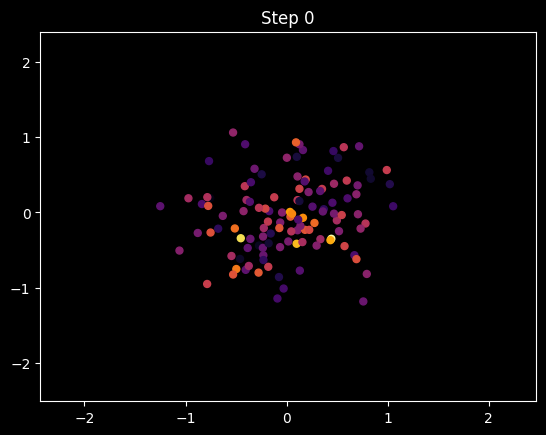

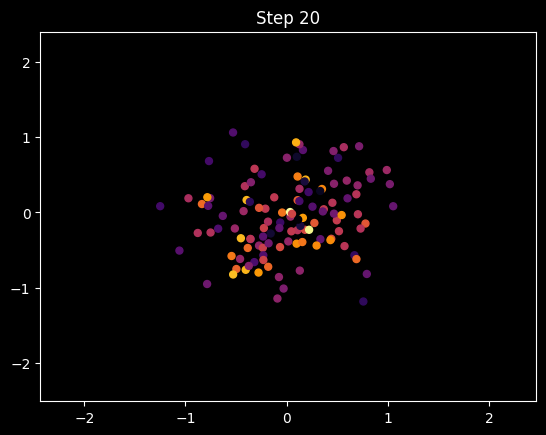

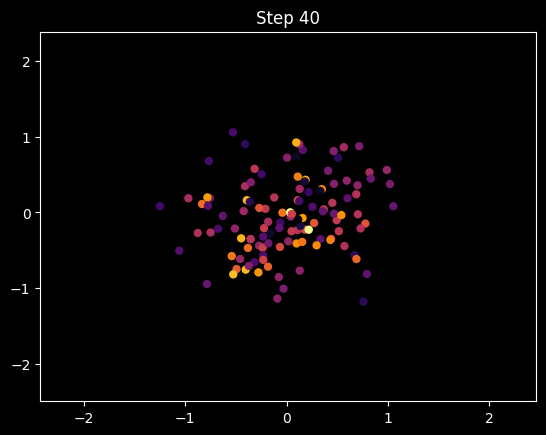

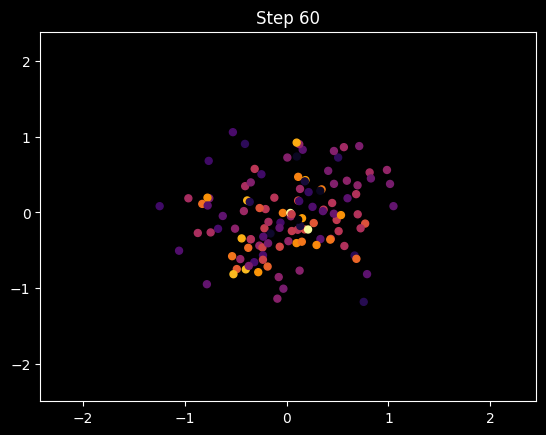

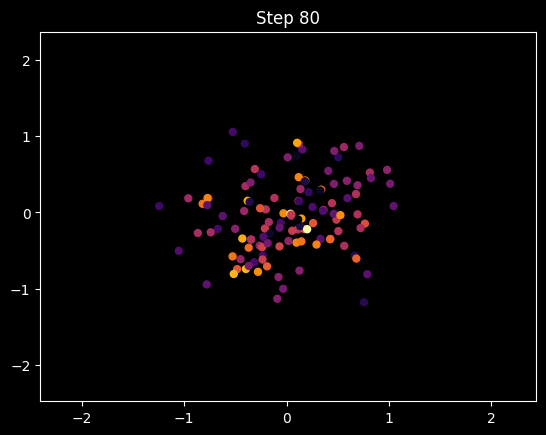

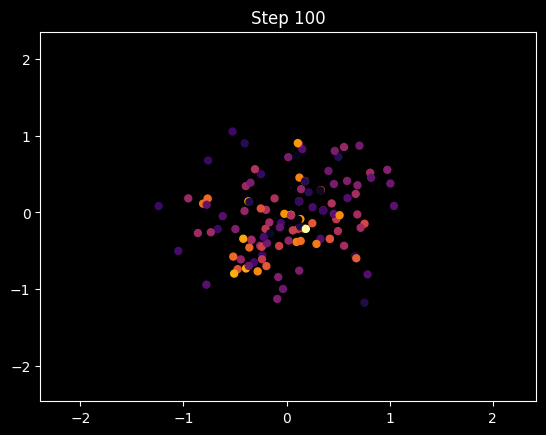

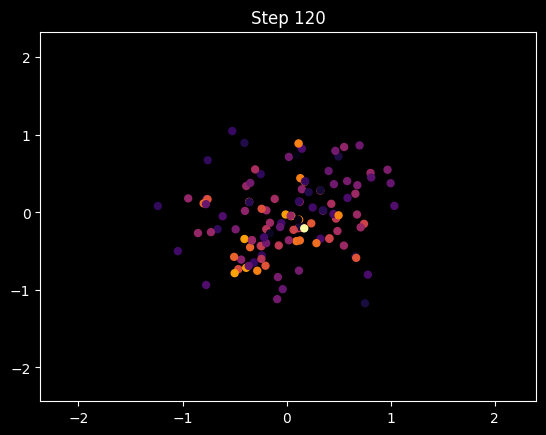

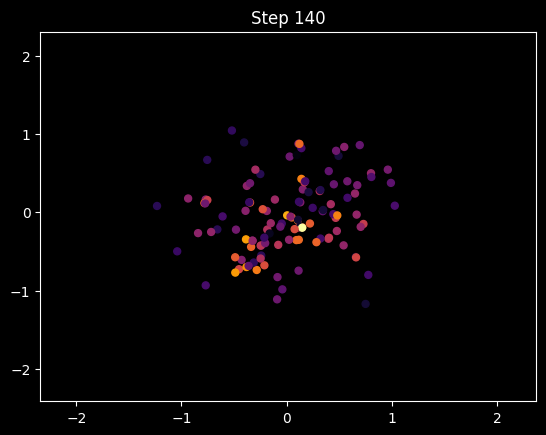

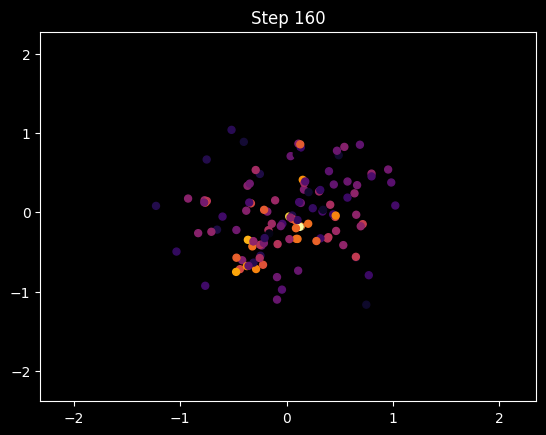

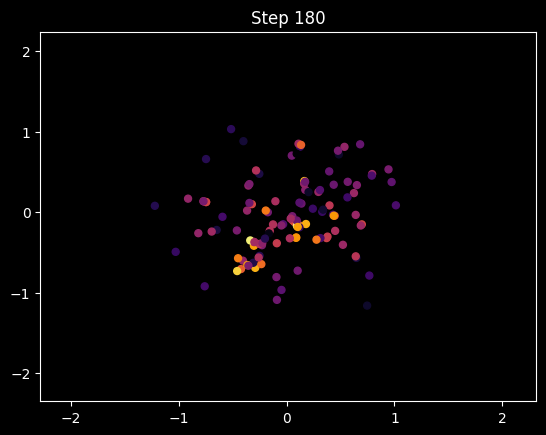

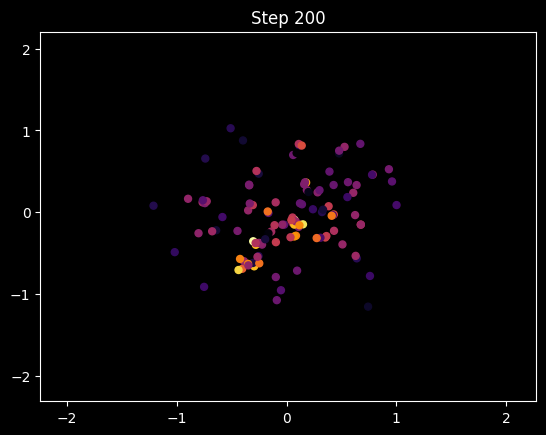

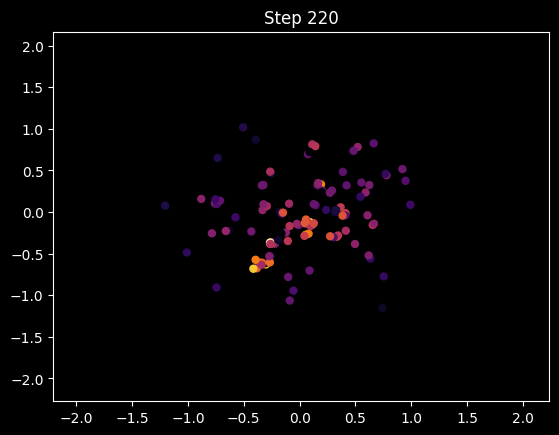

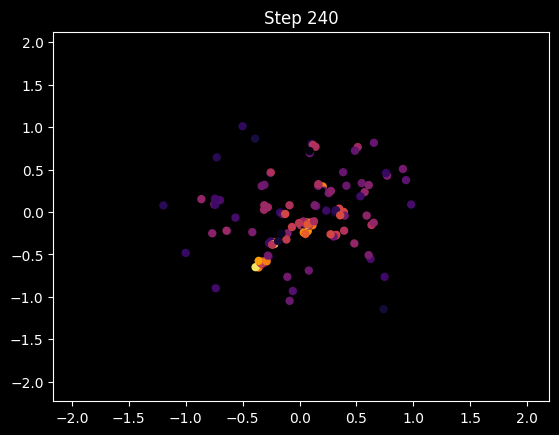

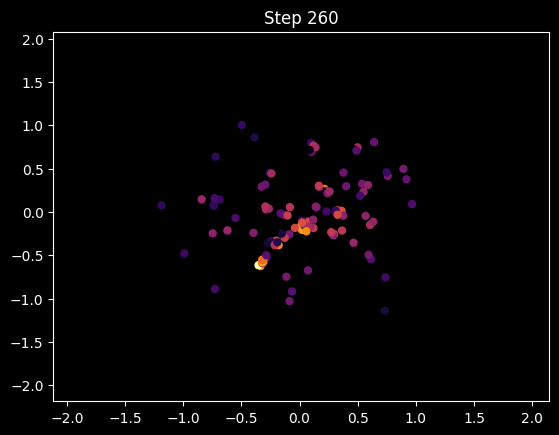

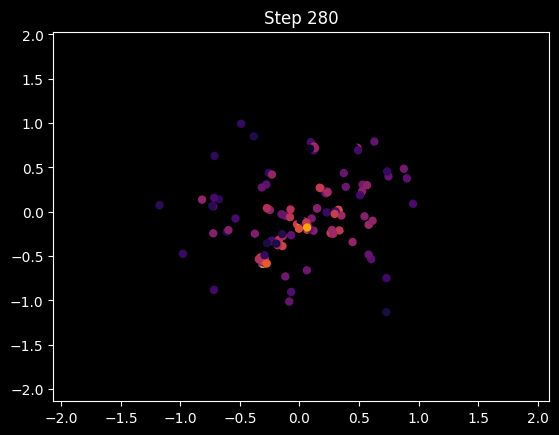

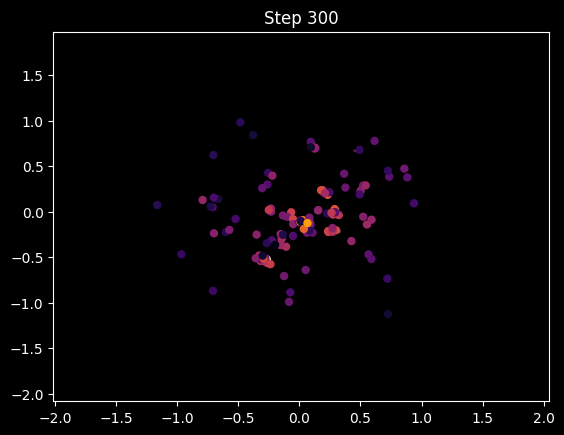

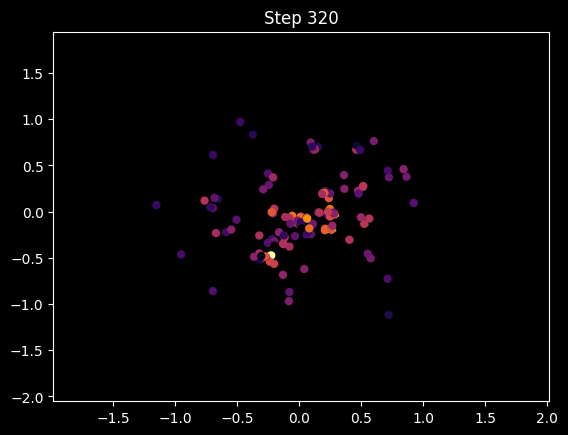

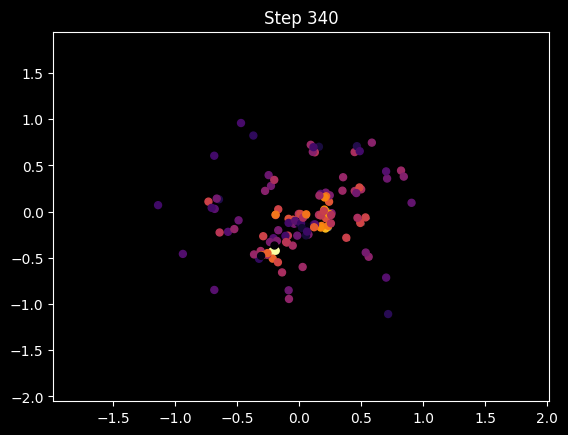

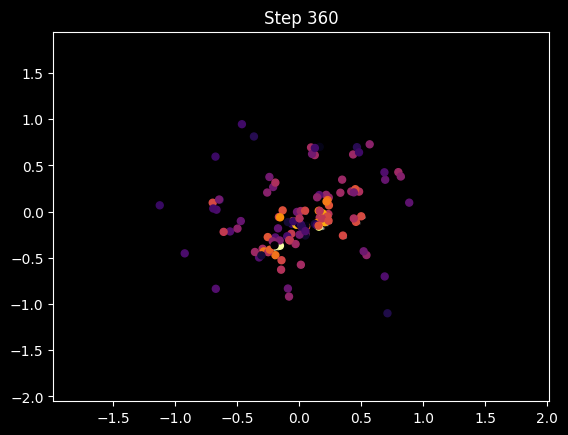

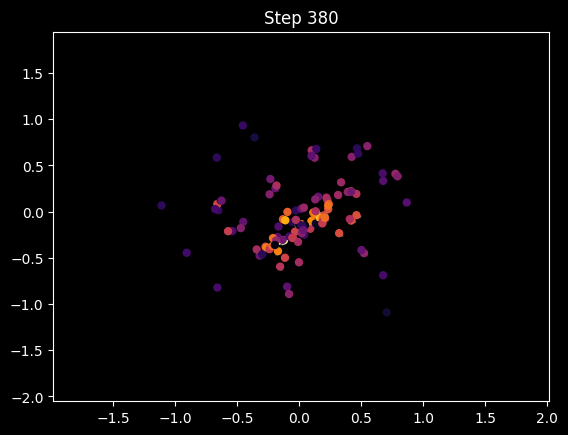

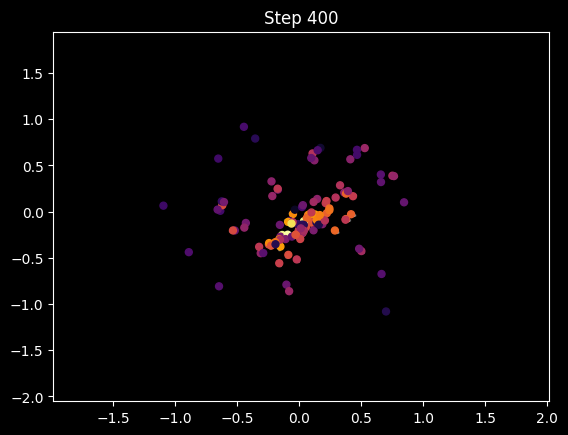

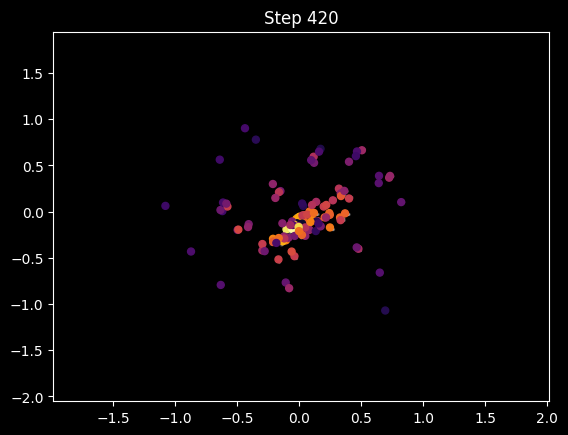

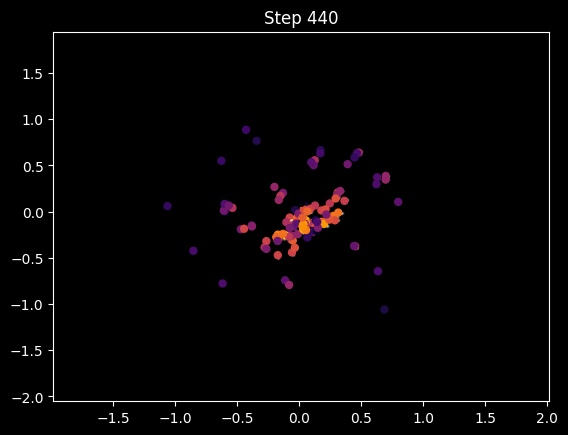

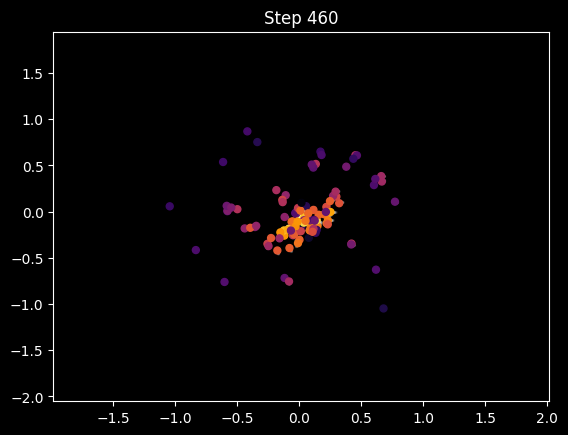

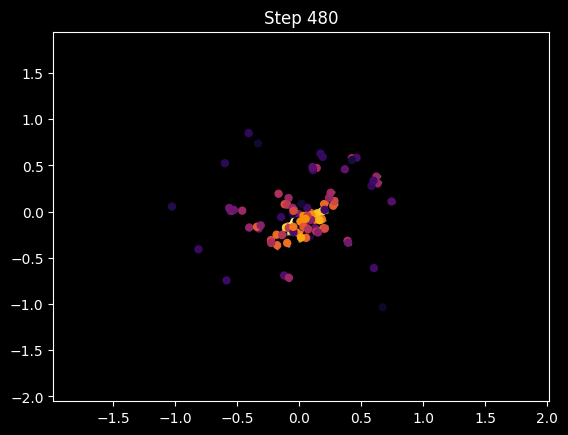

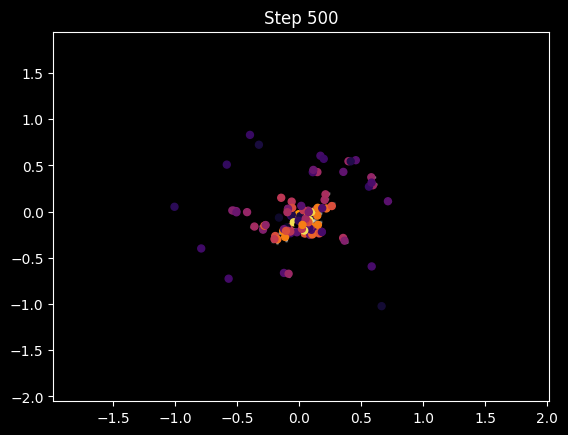

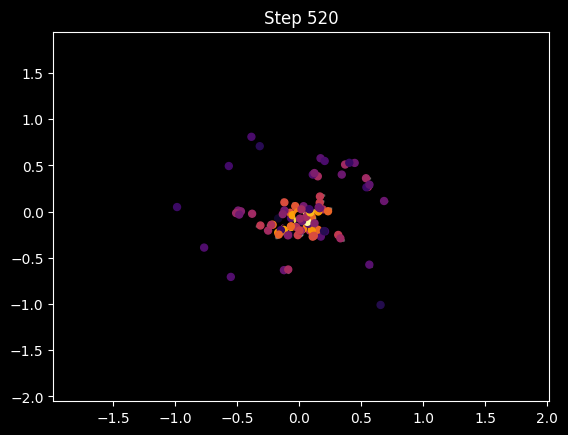

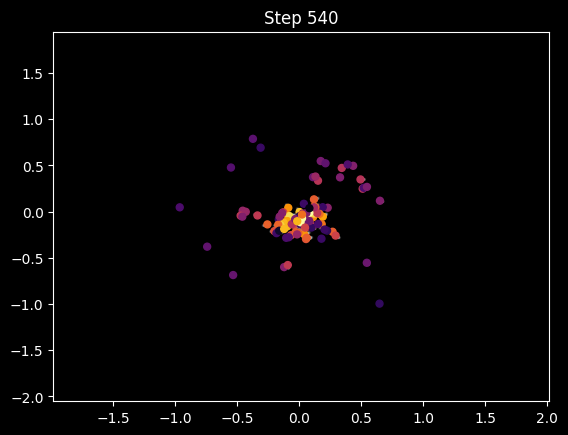

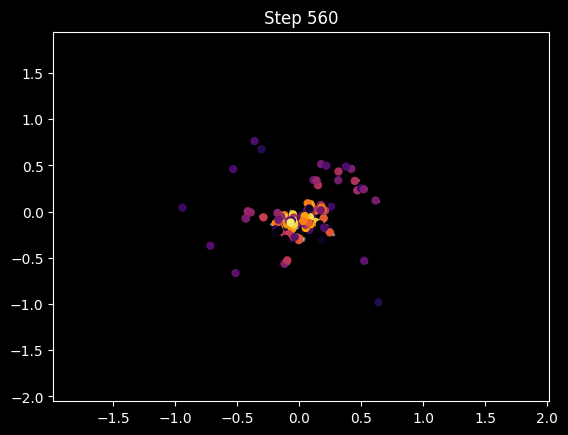

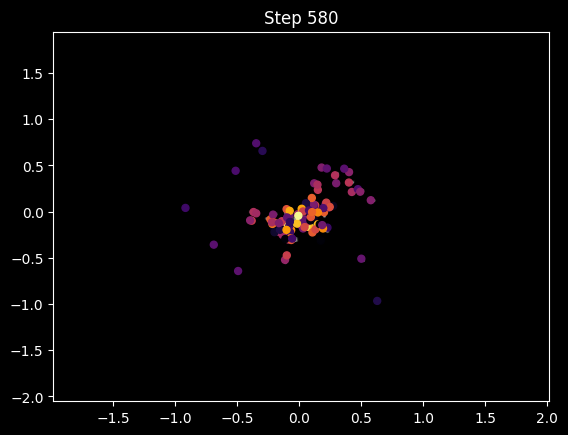

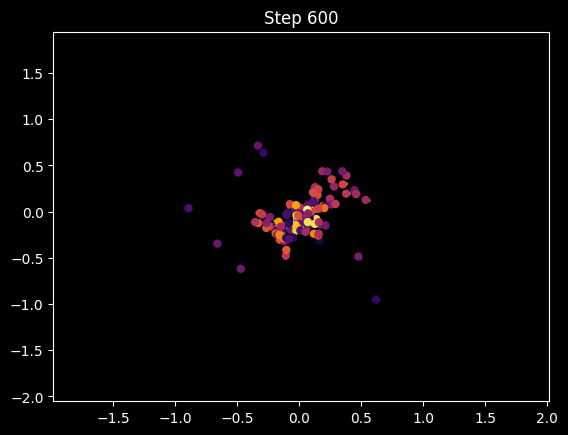

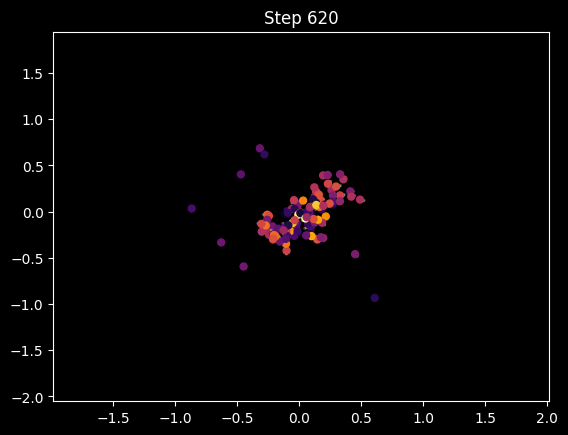

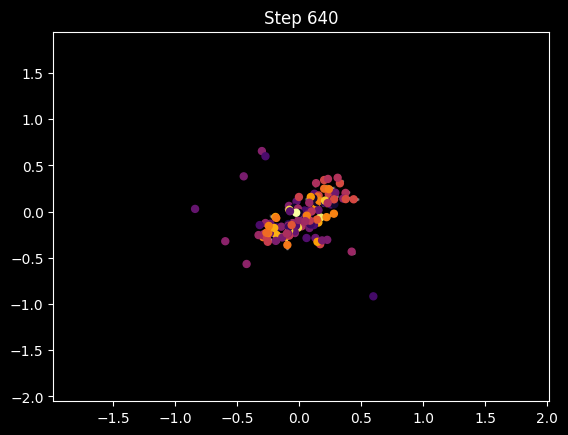

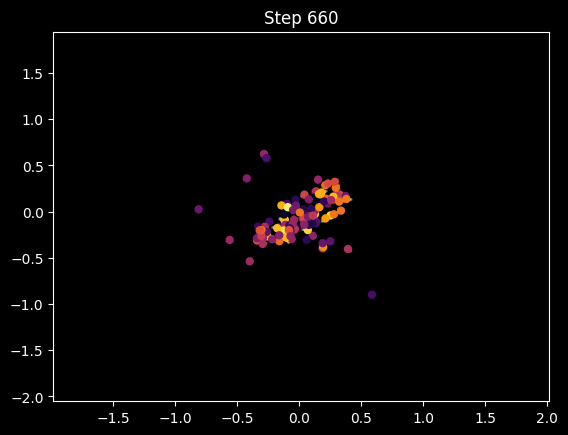

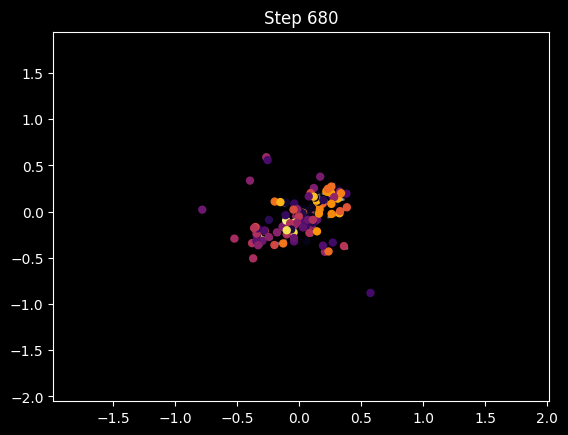

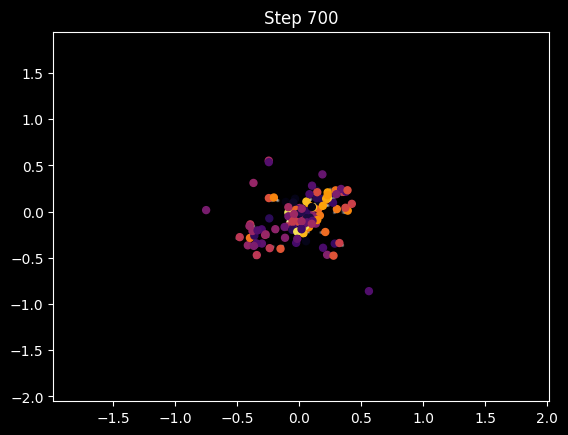

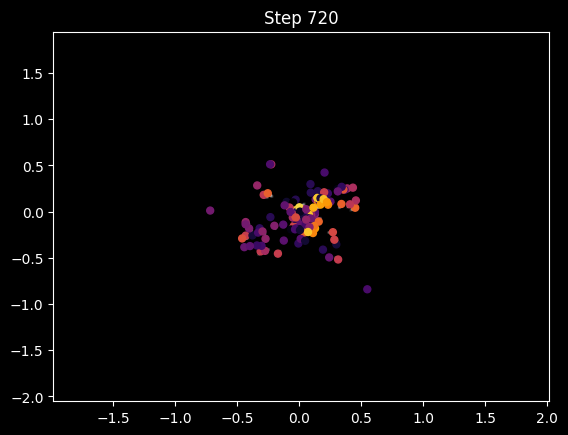

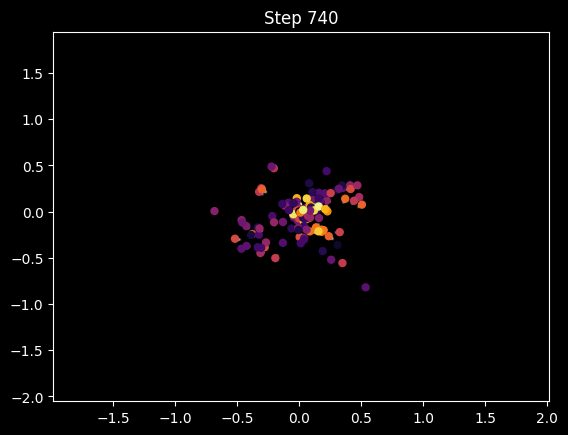

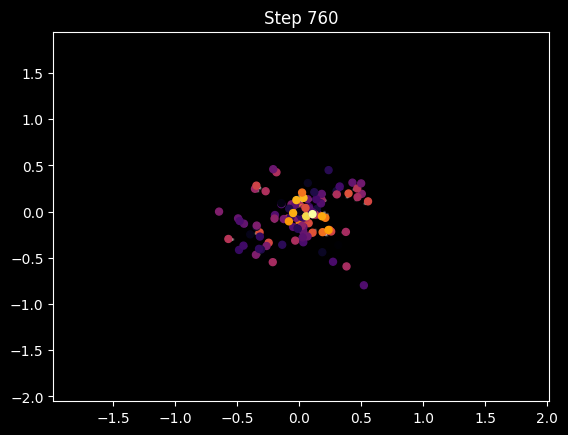

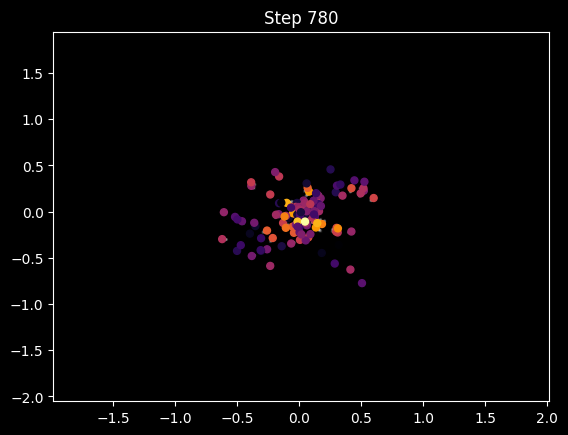

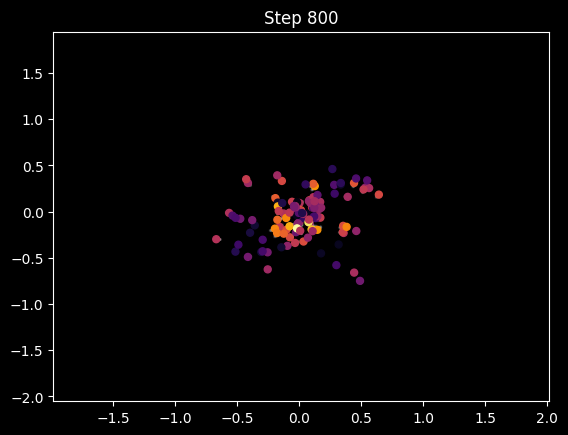

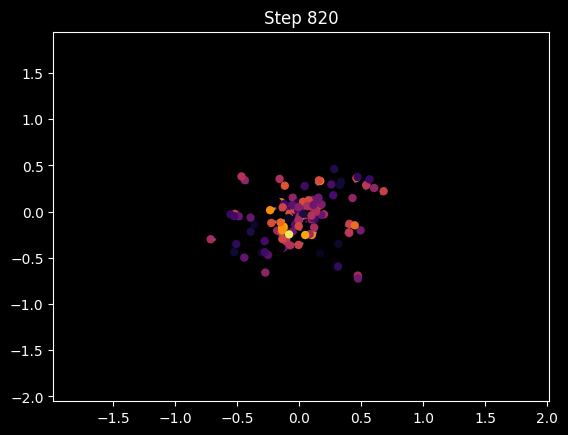

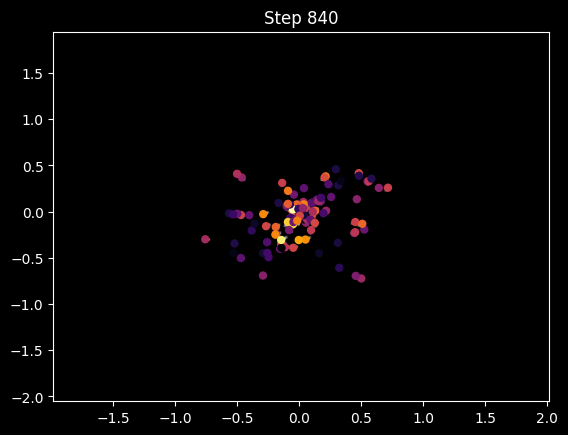

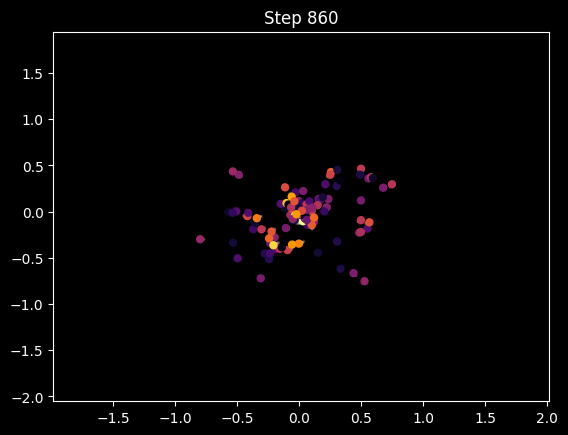

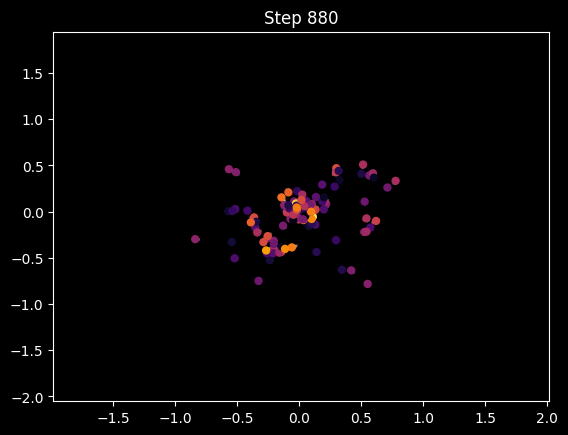

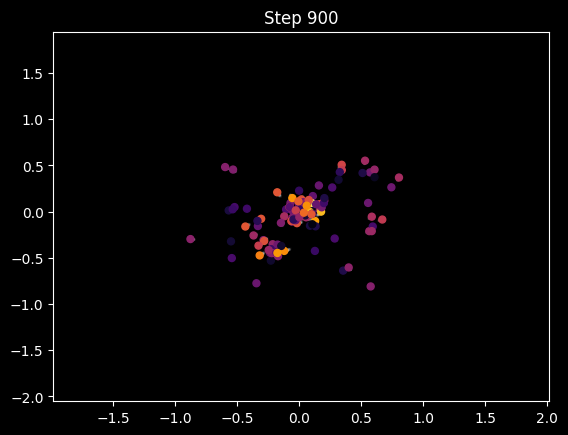

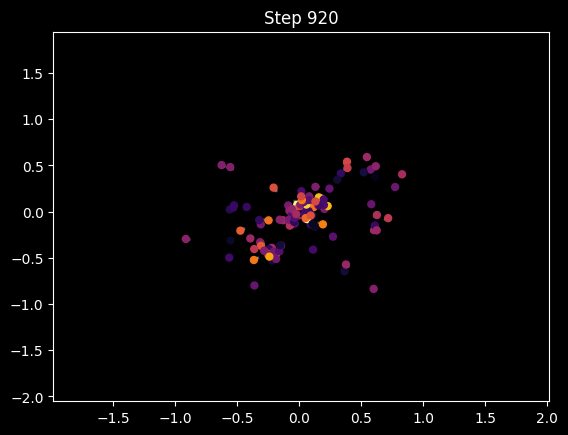

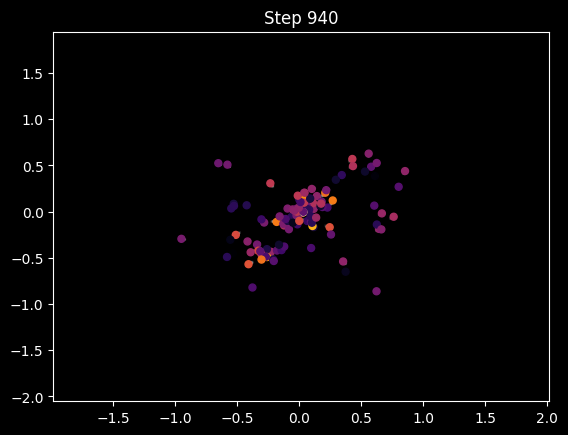

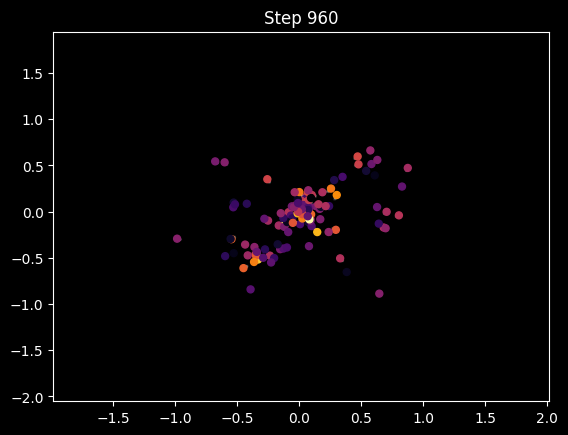

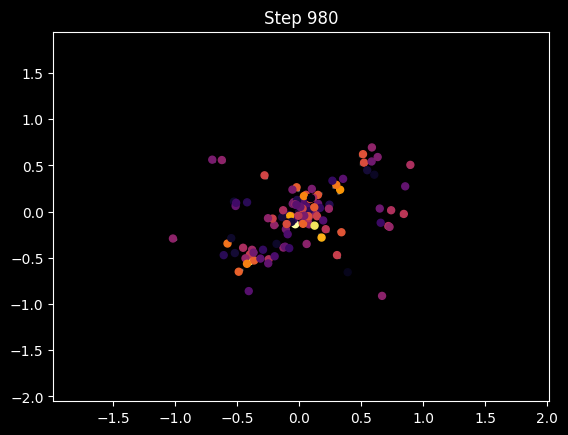

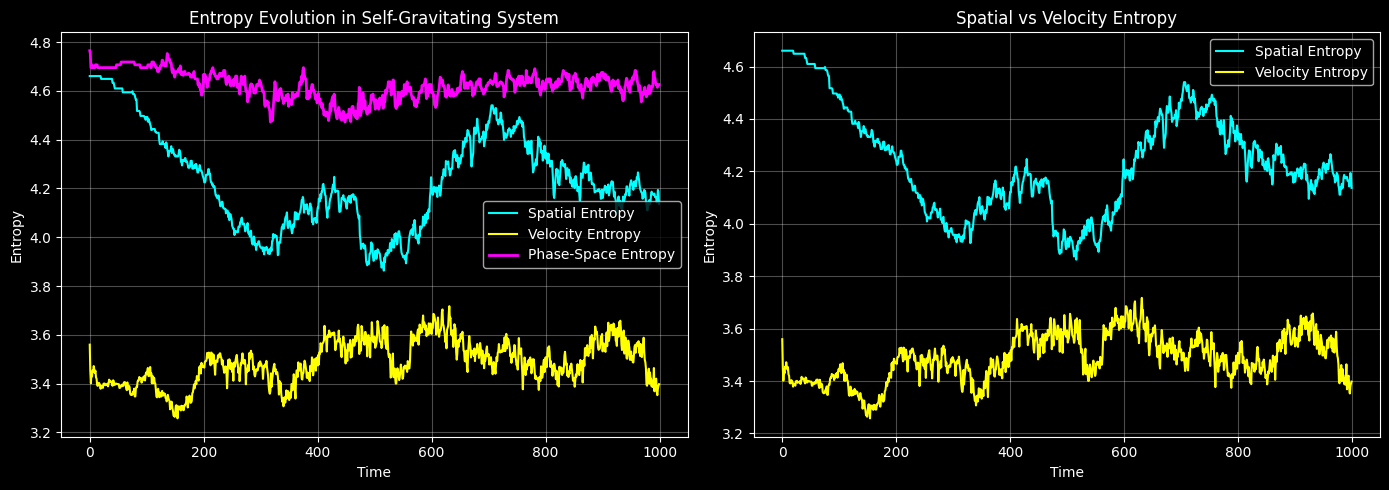

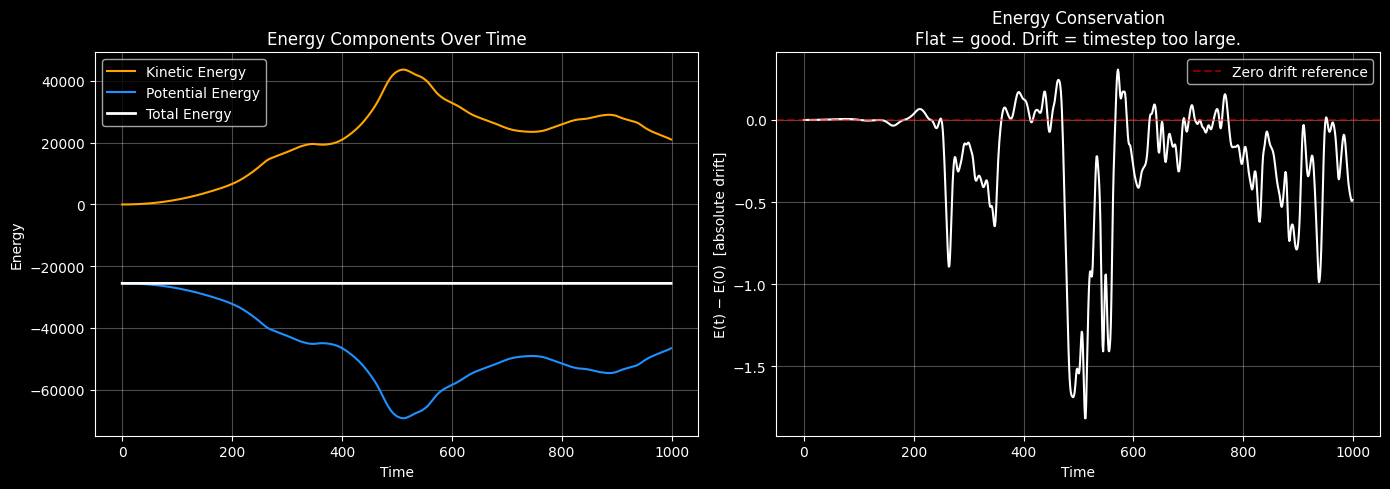

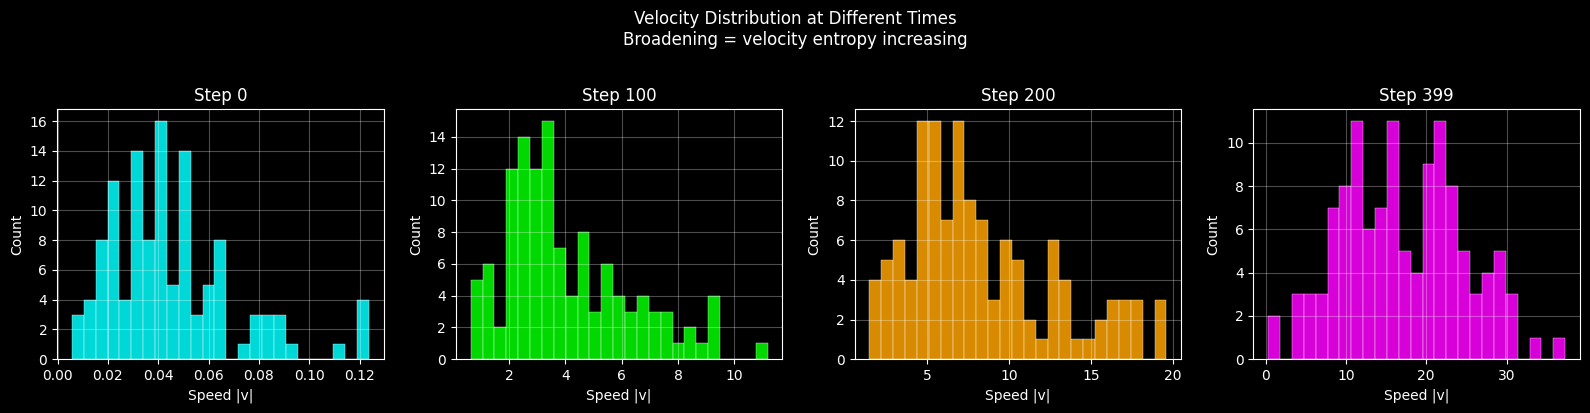

Done. Saved: entropy_evolution.png, energy_conservation.png, velocity_distributions.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# PARAMETERS

N = 120
G = 2.0
dt = 0.0001
steps = 1000
epsilon = 0.05


# FORCE FUNCTION (vectorized - much faster)

def compute_forces(pos):
    diff = pos[:, np.newaxis, :] - pos[np.newaxis, :, :]   # (N, N, 2)
    dist2 = np.sum(diff**2, axis=-1) + epsilon**2           # (N, N)
    dist3 = dist2**1.5                                      # (N, N)
    np.fill_diagonal(dist3, np.inf)                         # no self-force
    forces = -G * np.sum(diff / dist3[:, :, np.newaxis], axis=1)
    return forces

# ENERGY FUNCTION

def compute_energy(pos, vel):
    KE = 0.5 * np.sum(vel**2)
    diff = pos[:, np.newaxis, :] - pos[np.newaxis, :, :]
    dist = np.sqrt(np.sum(diff**2, axis=-1) + epsilon**2)
    i_idx, j_idx = np.triu_indices(N, k=1)
    PE = -G * np.sum(1.0 / dist[i_idx, j_idx])
    return KE + PE, KE, PE


# ENTROPY FUNCTIONS

def spatial_entropy(pos, bins=30):
    H, _, _ = np.histogram2d(pos[:, 0], pos[:, 1], bins=bins)
    p = H / np.sum(H)
    p = p[p > 0]
    return -np.sum(p * np.log(p))

def velocity_entropy(vel, bins=50):
    v = np.linalg.norm(vel, axis=1)
    hist, _ = np.histogram(v, bins=bins)
    p = hist / np.sum(hist)
    p = p[p > 0]
    return -np.sum(p * np.log(p))

def phase_space_entropy(pos, vel, bins=10):
    data = np.hstack([pos, vel])
    data_min = data.min(axis=0)
    data_max = data.max(axis=0)
    data_range = data_max - data_min
    data_range[data_range == 0] = 1
    data_norm = (data - data_min) / data_range
    H, _ = np.histogramdd(data_norm, bins=bins, range=[[0, 1]] * 4)
    p = H / np.sum(H)
    p = p[p > 0]
    return -np.sum(p * np.log(p))


# VELOCITY VERLET UPDATE

def update(pos, vel):
    forces = compute_forces(pos)
    vel += 0.5 * forces * dt
    pos += vel * dt
    forces_new = compute_forces(pos)
    vel += 0.5 * forces_new * dt
    return pos, vel


# INITIAL CONDITIONS
# (defined AFTER functions so compute_energy is available)

pos = np.random.normal(0.0, 0.5, (N, 2))
vel = np.random.randn(N, 2) * 0.02
vel -= np.mean(vel, axis=0)

E0, _, _ = compute_energy(pos, vel)
print(f"Initial total energy: {E0:.4f}")


# PART 1: ANIMATION WITH TRAILS

history = []

pos = np.random.normal(0.0, 0.5, (N, 2))
vel = np.random.randn(N, 2) * 0.02
vel -= np.mean(vel, axis=0)

for step in range(steps):
    pos, vel = update(pos, vel)

    history.append(pos.copy())
    if len(history) > 15:
        history.pop(0)

    if step % 20 == 0:
        plt.clf()

        for i, past in enumerate(history):
            plt.scatter(past[:, 0], past[:, 1],
                        color='white',
                        alpha=0.02 + 0.02 * i,
                        s=2)

        speeds = np.linalg.norm(vel, axis=1)
        plt.scatter(pos[:, 0], pos[:, 1],
                    c=speeds, cmap='inferno', s=25)

        center = np.mean(pos, axis=0)
        spread = np.std(pos)
        scale = max(2.0, 5 * spread)

        plt.xlim(center[0] - scale, center[0] + scale)
        plt.ylim(center[1] - scale, center[1] + scale)
        plt.title(f"Step {step}")
        plt.pause(0.01)

plt.show()


# PART 2: FULL DATA COLLECTION RUN

pos = np.random.normal(0.0, 0.5, (N, 2))
vel = np.random.randn(N, 2) * 0.02
vel -= np.mean(vel, axis=0)

S_space  = []
S_vel    = []
S_phase  = []
E_total  = []
E_kin    = []
E_pot    = []
time_arr = []

for step in range(steps):
    pos, vel = update(pos, vel)

    S_space.append(spatial_entropy(pos))
    S_vel.append(velocity_entropy(vel))
    S_phase.append(phase_space_entropy(pos, vel))

    E, KE, PE = compute_energy(pos, vel)
    E_total.append(E)
    E_kin.append(KE)
    E_pot.append(PE)

    time_arr.append(step)

# PLOT 1: ENTROPY EVOLUTION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(time_arr, S_space, label="Spatial Entropy",     color='cyan')
axes[0].plot(time_arr, S_vel,   label="Velocity Entropy",    color='yellow')
axes[0].plot(time_arr, S_phase, label="Phase-Space Entropy", color='magenta', linewidth=2)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Entropy")
axes[0].set_title("Entropy Evolution in Self-Gravitating System")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(time_arr, S_space, label="Spatial Entropy",  color='cyan')
axes[1].plot(time_arr, S_vel,   label="Velocity Entropy", color='yellow')
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Entropy")
axes[1].set_title("Spatial vs Velocity Entropy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("entropy_evolution.png", dpi=150, bbox_inches='tight')
plt.show()


# PLOT 2: ENERGY CONSERVATION
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(time_arr, E_kin,   label="Kinetic Energy",   color='orange')
axes[0].plot(time_arr, E_pot,   label="Potential Energy", color='dodgerblue')
axes[0].plot(time_arr, E_total, label="Total Energy",     color='white', linewidth=2)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Energy")
axes[0].set_title("Energy Components Over Time")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Absolute drift — avoids near-zero denominator problem
E_drift = np.array(E_total) - E_total[0]
axes[1].plot(time_arr, E_drift, color='white', linewidth=1.5)
axes[1].axhline(0.0, color='red', linestyle='--', alpha=0.5, label="Zero drift reference")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("E(t) − E(0)  [absolute drift]")
axes[1].set_title("Energy Conservation\nFlat = good. Drift = timestep too large.")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("energy_conservation.png", dpi=150, bbox_inches='tight')
plt.show()

# PLOT 3: VELOCITY DISTRIBUTION SNAPSHOTS

snapshot_steps = [0, 100, 200, 399]
snapshots = {}

pos_snap = np.random.normal(0.0, 0.5, (N, 2))
vel_snap = np.random.randn(N, 2) * 0.02
vel_snap -= np.mean(vel_snap, axis=0)

for step in range(steps):
    pos_snap, vel_snap = update(pos_snap, vel_snap)
    if step in snapshot_steps:
        snapshots[step] = np.linalg.norm(vel_snap, axis=1).copy()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['cyan', 'lime', 'orange', 'magenta']

for ax, (step, color) in zip(axes, zip(snapshot_steps, colors)):
    ax.hist(snapshots[step], bins=25, color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.set_title(f"Step {step}")
    ax.set_xlabel("Speed |v|")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)

fig.suptitle("Velocity Distribution at Different Times\n"
             "Broadening = velocity entropy increasing", y=1.02)
plt.tight_layout()
plt.savefig("velocity_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

print("Done. Saved: entropy_evolution.png, energy_conservation.png, velocity_distributions.png")